In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

# -- Alternatively, use Groq --------------------------------------------------
# from langchain_groq import ChatGroq
# llm = ChatGroq(model="llama-3.3-70b-versatile")
# ------------------------------------------------------------------------------

print("LLM ready.")

LLM ready.


In [2]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class AgentState(TypedDict):
    # add_messages appends new messages instead of replacing the whole list
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState ready.")

AgentState ready.


In [4]:
def call_llm(state: AgentState) -> dict:
    """One graph node: call the LLM using the current messages."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
def test_graph(state: AgentState) -> dict:
    """One graph node: call the LLM using the current messages."""
    response = f"Testing"
    return {"messages": [response]}

In [6]:
# Build the graph
simple_builder = StateGraph(AgentState)
simple_builder.add_node("assistant", call_llm)
simple_builder.add_node("assistant2", test_graph)



simple_builder.add_edge(START, "assistant")
simple_builder.add_edge("assistant", "assistant2")
simple_builder.add_edge("assistant2", END)

In [7]:
simple_graph = simple_builder.compile()

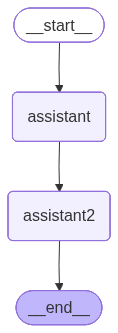

In [10]:
simple_graph

In [8]:
simple_result = simple_graph.invoke({
    "messages": [("user", "Explain LangGraph in one sentence.")]
})

print(simple_result["messages"][-1].content)
print()
print(f"Messages in final state: {len(simple_result['messages'])}")

Testing

Messages in final state: 3


In [9]:
for i, msg in enumerate(simple_result["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:90] + "..." if len(text) > 90 else text
    print(f"[{i}] {role}: {text}")

[1] Human: Explain LangGraph in one sentence.
[2] AI: LangGraph is a Python library that lets you construct, visualize, and run dynamic, state‑d...
[3] Human: Testing
